In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/nigeria.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [2]:
# Replace -999
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73


In [3]:
# Create DATE column
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [4]:
# Add Month
df["Month"] = df["DATE"].dt.month


In [5]:
# Add Country column
df["Country"] = "Ethiopia"

In [6]:
df.duplicated().sum()

np.int64(0)

No duplicate rows found

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


- Average temperature (T2M) is approximately 26.66°C, with daily maximums (T2M_MAX) reaching up to 32.88°C.
- Precipitation (PRECTOTCORR) is highly variable, ranging from 0 mm to 166.10 mm, showing much more extreme rainfall events than previous data.
- Humidity (RH2M) is consistently high, ranging from 54.4% to 93.79% → this suggests a much more humid or tropical climate overall.
- Wind Speed (WS2M) is generally low, averaging around 2.22 m/s, with peak gusts (WS2M_MAX) reaching 6.00 m/s.

In [8]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
DATE           0
Month          0
Country        0
dtype: int64

- Dataset has negligible missing values (<1%)
- Forward fill was applied for consistency

In [9]:
(df.isna().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
DATE           0.0
Month          0.0
Country        0.0
dtype: float64

In [10]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[[
    "T2M", "T2M_MAX", "T2M_MIN", 
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]].dropna()))

outliers = (z_scores > 3).sum()
outliers

np.int64(297)

- 137 outliers detected using Z-score > 3
- Outliers retained because they may represent extreme climate events

In [11]:
df = df.ffill()

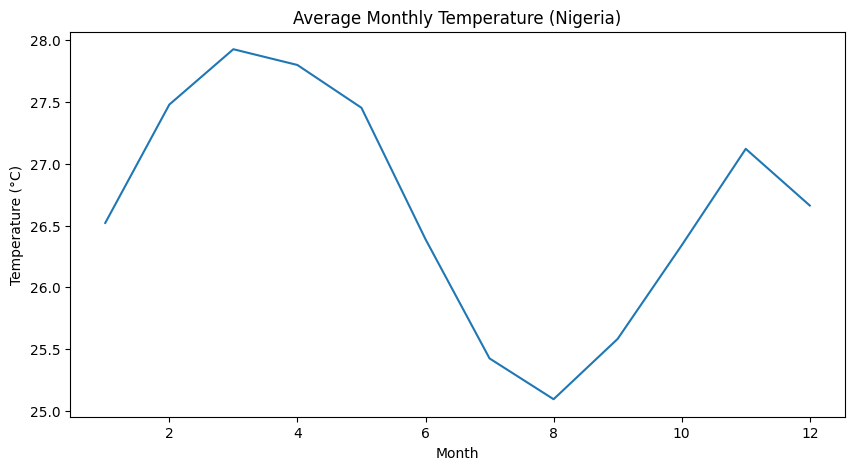

In [13]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line", figsize=(10,5))
plt.title("Average Monthly Temperature (Nigeria)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

- Highest temprature occur around April
- Lowest temprature occur around  Augest

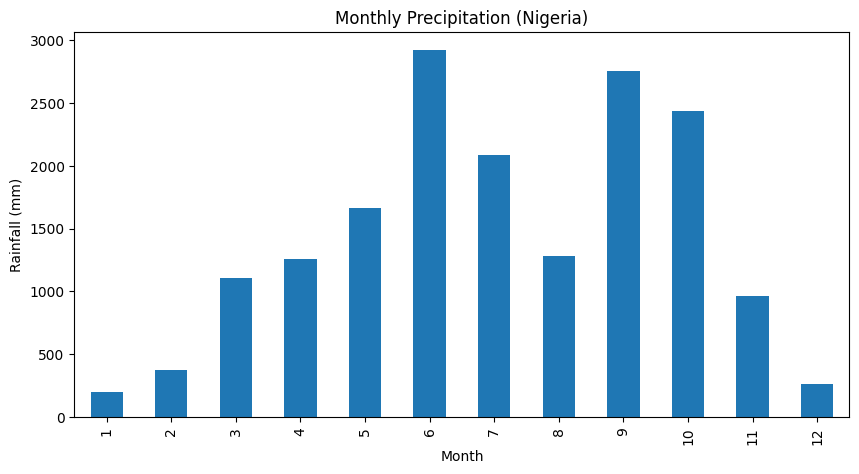

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Precipitation (Nigeria)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")
plt.show()

- Rainfall peaks in June
- Less rainfall on Decemeber-January

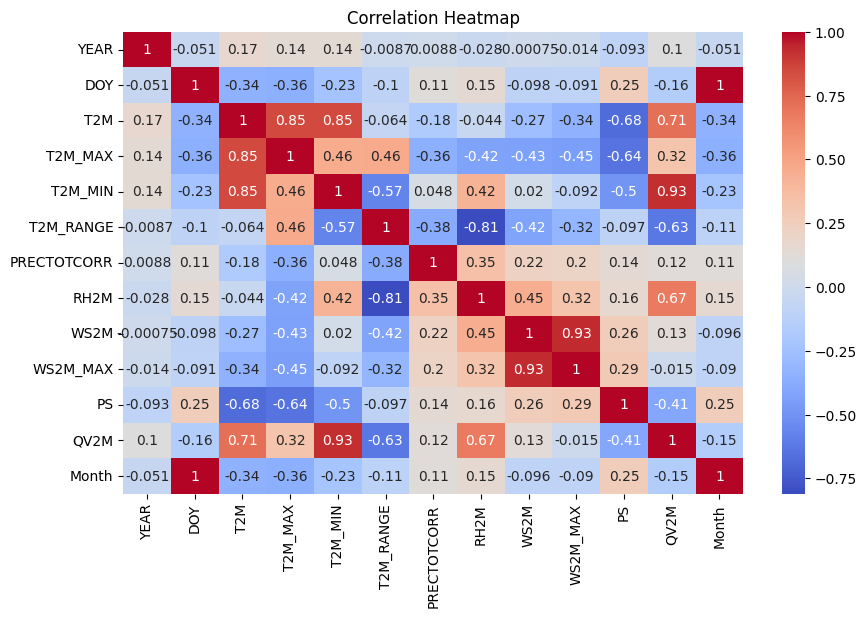

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- T2M vs T2M_MAX & T2M_MIN: There is a very strong positive correlation (0.85), showing that average temperature is driven equally by both daily highs and lows.
- RH2M vs T2M_RANGE: A strong negative correlation (-0.81) indicates that days with a wider temperature range are significantly less humid.
- WS2M vs WS2M_MAX: An extremely high correlation (0.93) confirms that average wind speeds and maximum gusts are nearly perfectly synchronized.
- QV2M vs T2M_MIN: A very strong positive correlation (0.93) suggests that higher overnight low temperatures are closely tied to higher moisture content in the air.


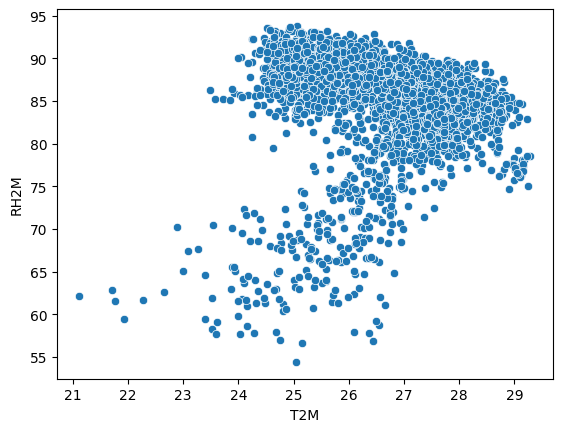

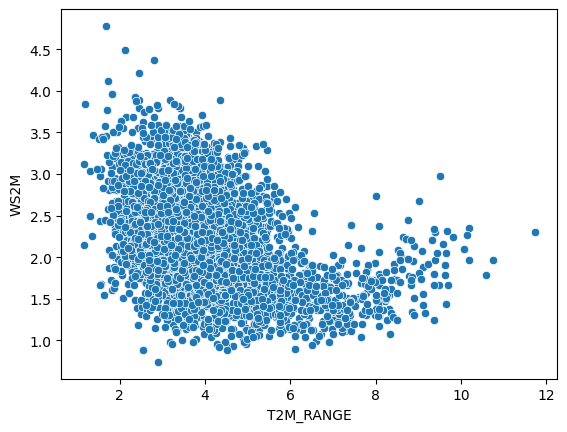

In [16]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

- T2M vs. RH2M: The data shows a dense cluster at high humidity (80-95%) across temperatures of 24°C to 28°C, suggesting a consistently humid and warm environment.
- T2M_RANGE vs. WS2M: There is a negative trend visible where higher wind speeds (above 3.5 m/s) occur when the temperature range is narrow (under 4°C), while wider ranges show lower, more stable wind speeds.


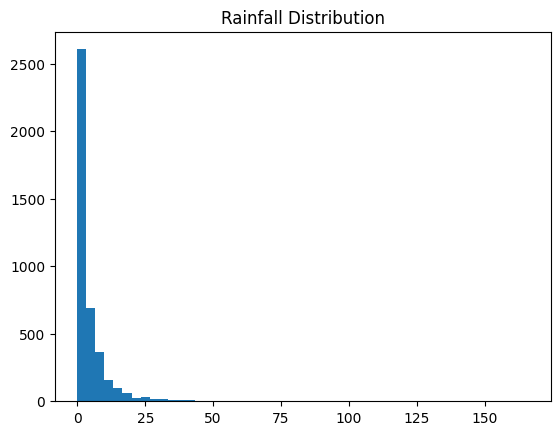

In [17]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

- few high values and many low vlaues

In [19]:
df.to_csv("../data/nigeria_clean.csv", index=False)